In [ ]:
from collections.abc import Callable

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from deep_isochron.model.latent_dynamics import (
    AbstractLatentDynamics,
    HopfLatentDynamics,
)
from einops import rearrange
from jaxtyping import Array, Float, PRNGKeyArray


jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("gpu")[1])


In [18]:
dyn = HopfLatentDynamics(dim=10, num_eig_comp=0, key=jax.random.key(0))
dyn.linear.eigenvalues

(Array([], shape=(0, 2), dtype=float64),
 Array([-1.29138111, -0.8631045 , -1.07735964, -1.30697225, -0.84435225,
        -0.88660562, -0.98987331, -0.86740485], dtype=float64))

In [19]:
ts = jnp.arange(0, 20.0, 0.01)
y0 = jax.random.uniform(jax.random.key(0), shape=(dyn.dim,))

In [20]:
out = dyn(ts, y0)

In [21]:
out.shape

(2000, 10)

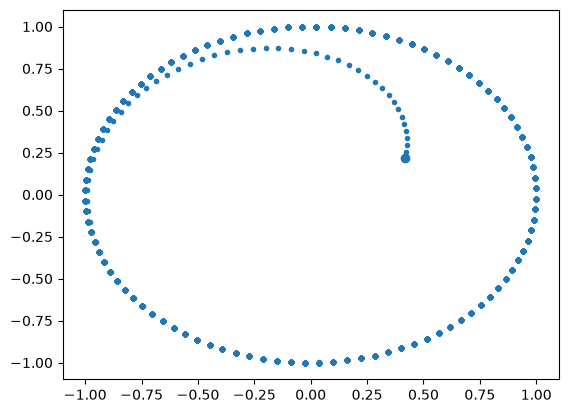

In [22]:
plt.plot(out[:, 0], out[:, 1], ".")
plt.scatter(y0[0], y0[1])

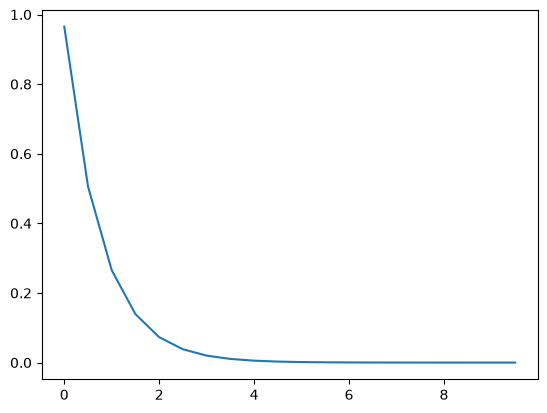

In [10]:
plt.plot(ts, out[:, 2])

In [7]:
rearrange(jnp.zeros(10), "(n d) -> n d", d=2).shape

(5, 2)

In [ ]:
class PhaseAmplitudeAutoencoder(eqx.Module):
    encoder: eqx.nn.MLP
    decoder: eqx.nn.MLP
    latent_dynamics: AbstractLatentDynamics

    def __init__(
        self,
        obs_dim: int,
        latent_dynamics: AbstractLatentDynamics,
        mlp_depth: int = 1,
        mlp_width: int = 32,
        activation: Callable = jax.nn.gelu,
        dtype=None,
        *,
        key: PRNGKeyArray,
    ):
        key_e, key_d = jax.random.split(key)
        self.latent_dynamics = latent_dynamics

        self.encoder = eqx.nn.MLP(
            in_size=obs_dim,
            out_size=self.latent_dim,
            width_size=mlp_width,
            depth=mlp_depth,
            activation=activation,
            dtype=dtype,
            key=key_e,
        )
        self.decoder = eqx.nn.MLP(
            in_size=self.latent_dim,
            out_size=obs_dim,
            width_size=mlp_width,
            depth=mlp_depth,
            activation=activation,
            dtype=dtype,
            key=key_d,
        )

    @property
    def latent_dim(self) -> int:
        return self.latent_dynamics.dim

    def __call__(
        self,
        ts: Float[Array, " time"],
        x0: Float[Array, " obs_dim"],
        return_latent_trajectory: bool = True,
    ) -> tuple[Float[Array, "time obs_dim"], Float[Array, "time latent_dim"] | None]:
        y0: Float[Array, " latent_dim"] = self.encoder(x0)
        yt: Float[Array, "time latent_dim"] = self.latent_dynamics(ts, y0)
        xt: Float[Array, "time obs_dim"] = eqx.filter_vmap(self.decoder)(yt)

        if return_latent_trajectory:
            return xt, yt
        else:
            return xt, None